# Figure 3: LRG Framework - Full Analysis Panels

This notebook generates comprehensive LRG (Laplacian Renormalization Group) analysis visualizations for each frequency band and phase.

## Contents

1. **Full LRG Panel** (5 subplots per band/phase):
   - FC Matrix heatmap
   - Entropy (1-S) and Specific Heat (C) curves
   - Hierarchical dendrogram with optimal threshold
   - Network with partition colors
   - Partition Stability Index (PSI)

2. **Density Matrix Animation**: 
   - GIF showing $\rho(\tau) = e^{-\tau L}$ filling over log-spaced $\tau$ values
   - Visualizes information diffusion across the network

## The Laplacian Propagator $\rho(\tau)$

The density matrix at diffusion time $\tau$ is:

$$\rho(\tau) = e^{-\tau L}$$

where $L$ is the normalized Laplacian:

$$L = I - D^{-1/2} A D^{-1/2}$$

**Physical interpretation**:
- At $\tau \to 0$: $\rho \approx I$ (no diffusion, each node isolated)
- At $\tau \to \infty$: $\rho \to \mathbf{1}\mathbf{1}^T/N$ (fully mixed, all nodes equivalent)
- Intermediate $\tau$: reveals hierarchical structure at different scales

In [1]:
# Setup
from lrgsglib.config.funcs import move_to_rootf
move_to_rootf(pathname='lrgeegfc')

from lrg_eegfc.notebook import *
path_figs = setup_notebook('figures/presentation_figures')

Current working directory: /home/giulio/Documents/research/neural_networks/lrgeegfc
✓ Notebook setup complete
  Figure output: data/figures/presentation_figures


In [2]:
# Additional imports
import sys
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
import numpy as np
from pathlib import Path
from scipy.linalg import expm
from IPython.display import HTML, Image

# Add notebook directory to path for local imports
notebook_dir = Path("ipynb/06_presentation_figures").resolve()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from presentation_utils import (
    compute_normalized_laplacian,
    compute_rho_matrix,
    create_rho_animation,
    CMAP_MATRIX,
)

## Configuration

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================
PATIENT = "Pat_02"
BANDS = BRAIN_BANDS_NAMES  # All 6 bands
PHASES = list(PHASE_LABELS)  # All 4 phases: rsPre, taskLearn, taskTest, rsPost

# Animation parameters
N_FRAMES = 150  # More frames = smoother animation
FPS = 20  # Higher FPS = faster playback
TAU_RANGE = (-3, 3)  # Log10 range for tau

# Paths
MSC_CACHE = Path("data/msc_cache")
LRG_CACHE = Path("data/lrg_cache")
OUTPUT_DIR = path_figs / PATIENT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Patient: {PATIENT}")
print(f"Bands: {BANDS}")
print(f"Phases: {PHASES}")
print(f"Animation: {N_FRAMES} frames at {FPS} fps")

Patient: Pat_02
Bands: ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
Phases: ['rsPre', 'taskLearn', 'taskTest', 'rsPost']
Animation: 150 frames at 20 fps


## Part 1: Generate Full LRG Panels

Using the existing `plot_lrg_full_panel` function.

In [ ]:
from lrg_eegfc.visuals.lrg import plot_lrg_full_panel
from lrg_eegfc.workflow.lrg import load_lrg_result
from lrg_eegfc.workflow.msc import load_msc_matrix

# Fixed number of communities for cross-phase comparison
# This ensures the same partition granularity across all phases
N_COMMUNITIES = 8  # Adjust as needed for comparison

# Generate panels for all band/phase combinations
print("Generating LRG full panels...")
print(f"Using fixed n_communities={N_COMMUNITIES} for cross-phase comparison")
print("="*60)

for band in BANDS:
    for phase in PHASES:
        # Check if data exists
        lrg_result = load_lrg_result(PATIENT, phase, band, "msc", cache_root=LRG_CACHE)
        if lrg_result is None:
            print(f"SKIP {band} {phase} - no LRG cache")
            continue
        
        output_path = OUTPUT_DIR / f"fig3_lrg_{band}_{phase}_v2.pdf"
        
        try:
            plot_lrg_full_panel(
                PATIENT,
                phase,
                band,
                fc_method="msc",
                cache_root=LRG_CACHE,
                output_path=output_path,
                figsize=(20, 12),
                verbose=False,
                n_communities=N_COMMUNITIES,  # Fixed for cross-phase comparison
            )
            print(f"OK   {band} {phase} -> {output_path.name}")
        except Exception as e:
            print(f"FAIL {band} {phase}: {e}")

print("\nDone with LRG panels!")

## Part 2: Density Matrix Animation $\rho(\tau)$

We'll create smooth GIF animations showing how the Laplacian propagator fills the network as $\tau$ increases.

In [ ]:
def create_rho_animation_smooth(
    adjacency: np.ndarray,
    output_path: Path,
    n_frames: int = 150,
    tau_range: tuple = (-3, 3),
    fps: int = 20,
    figsize: tuple = (10, 8),
    cmap: str = "inferno",
    title: str = "",
) -> Path:
    """Create smooth animation of rho(tau) matrix filling.
    
    The colormap is normalized dynamically:
    - vmax = max value at tau_start (near identity, diagonal ~1)
    - vmin = min value at tau_end (uniform ~1/N)
    
    This shows the dynamic evolution as information spreads across the network.
    
    Parameters
    ----------
    adjacency : np.ndarray
        Adjacency matrix
    output_path : Path
        Output path for GIF
    n_frames : int
        Number of frames
    tau_range : tuple
        (log10_min, log10_max) for tau values
    fps : int
        Frames per second
    figsize : tuple
        Figure size
    cmap : str
        Colormap
    title : str
        Title prefix
        
    Returns
    -------
    Path
        Path to saved GIF
    """
    # Compute normalized Laplacian
    L = compute_normalized_laplacian(adjacency)
    n_nodes = L.shape[0]
    
    # Generate tau values (log-spaced)
    tau_values = np.logspace(tau_range[0], tau_range[1], n_frames)
    
    # Pre-compute all rho matrices
    print(f"Pre-computing {n_frames} rho matrices...")
    rho_matrices = []
    for i, tau in enumerate(tau_values):
        rho = expm(-tau * L)
        rho_matrices.append(rho)
        if (i + 1) % 30 == 0:
            print(f"  Computed {i+1}/{n_frames}")
    
    # Dynamic colormap normalization:
    # vmax = max at beginning (tau→0, near identity)
    # vmin = min at end (tau→∞, uniform 1/N)
    vmax = rho_matrices[0].max()  # Start: diagonal ~1
    vmin = rho_matrices[-1].min()  # End: uniform ~1/N
    
    print(f"Colormap range: vmin={vmin:.4f}, vmax={vmax:.4f}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Initial plot with dynamic normalization
    im = ax.imshow(rho_matrices[0], cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\rho_{ij}(\tau)$", fontsize=14)
    
    title_text = ax.set_title(
        f"{title}\n" + r"$\rho(\tau) = e^{-\tau L}$" + f"   |   " + r"$\tau$ = {:.2e}".format(tau_values[0]),
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel("Node", fontsize=12)
    ax.set_ylabel("Node", fontsize=12)
    
    # Add tau indicator bar at bottom
    ax_tau = fig.add_axes([0.15, 0.02, 0.7, 0.02])
    ax_tau.set_xlim(tau_range[0], tau_range[1])
    ax_tau.set_ylim(0, 1)
    tau_marker, = ax_tau.plot([tau_range[0]], [0.5], 'r|', markersize=20, markeredgewidth=3)
    ax_tau.set_xlabel(r"$\log_{10}(\tau)$", fontsize=11)
    ax_tau.set_yticks([])
    ax_tau.set_facecolor('lightgray')
    
    def update(frame):
        im.set_array(rho_matrices[frame])
        title_text.set_text(
            f"{title}\n" + r"$\rho(\tau) = e^{-\tau L}$" + f"   |   " + r"$\tau$ = {:.2e}".format(tau_values[frame])
        )
        tau_marker.set_xdata([np.log10(tau_values[frame])])
        return [im, title_text, tau_marker]
    
    print(f"Creating animation with {n_frames} frames at {fps} fps...")
    anim = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=1000/fps, blit=True
    )
    
    # Save as GIF
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    writer = animation.PillowWriter(fps=fps)
    anim.save(str(output_path), writer=writer, dpi=100)
    plt.close(fig)
    
    print(f"Saved animation: {output_path}")
    return output_path

In [6]:
# Generate animations for selected bands/phases
# (Generating all 24 combinations would take a while, so we select key ones)

SELECTED_ANIMATIONS = [
    ("beta", "rsPre"),
    ("beta", "rsPost"),
    ("alpha", "rsPre"),
    ("theta", "rsPre"),
]

print("Generating rho(tau) animations...")
print("="*60)

for band, phase in SELECTED_ANIMATIONS:
    # Load MSC matrix
    msc_matrix = load_msc_matrix(
        PATIENT, phase, band,
        cache_root=MSC_CACHE,
        sparsify="none",
        n_surrogates=0,
        nperseg=1024,
    )
    
    if msc_matrix is None:
        print(f"SKIP {band} {phase} - no MSC data")
        continue
    
    output_path = OUTPUT_DIR / f"fig3_rho_animation_{band}_{phase}.gif"
    
    try:
        create_rho_animation_smooth(
            msc_matrix,
            output_path,
            n_frames=N_FRAMES,
            tau_range=TAU_RANGE,
            fps=FPS,
            title=f"{PATIENT} - {band.upper()} {phase}",
        )
        print(f"\nOK   {band} {phase}")
    except Exception as e:
        print(f"\nFAIL {band} {phase}: {e}")

print("\nDone with animations!")

Generating rho(tau) animations...
Pre-computing 150 rho matrices...
  Computed 30/150
  Computed 60/150
  Computed 90/150
  Computed 120/150
  Computed 150/150
Creating animation with 150 frames at 20 fps...
Saved animation: data/figures/presentation_figures/Pat_02/fig3_rho_animation_beta_rsPre.gif

OK   beta rsPre
Pre-computing 150 rho matrices...
  Computed 30/150
  Computed 60/150
  Computed 90/150
  Computed 120/150
  Computed 150/150
Creating animation with 150 frames at 20 fps...
Saved animation: data/figures/presentation_figures/Pat_02/fig3_rho_animation_beta_rsPost.gif

OK   beta rsPost
Pre-computing 150 rho matrices...
  Computed 30/150
  Computed 60/150
  Computed 90/150
  Computed 120/150
  Computed 150/150
Creating animation with 150 frames at 20 fps...
Saved animation: data/figures/presentation_figures/Pat_02/fig3_rho_animation_alpha_rsPre.gif

OK   alpha rsPre
Pre-computing 150 rho matrices...
  Computed 30/150
  Computed 60/150
  Computed 90/150
  Computed 120/150
  Comp

## Display sample animation

Displaying: data/figures/presentation_figures/Pat_02/fig3_rho_animation_beta_rsPre.gif


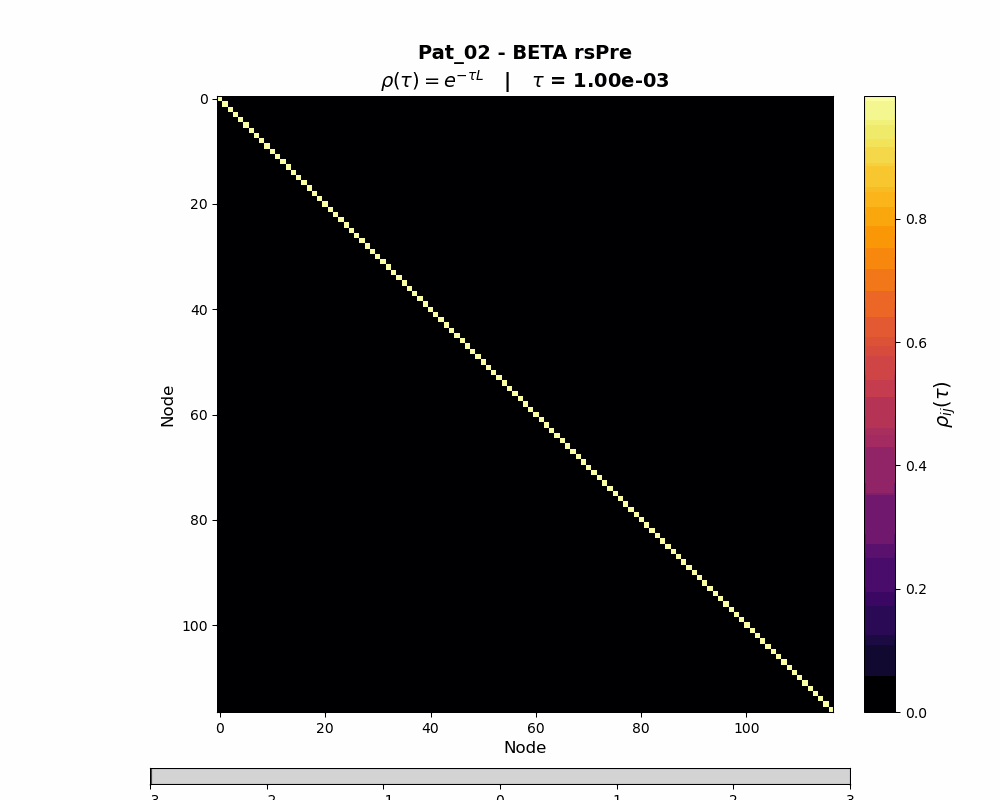

In [7]:
# Display one animation as example
sample_gif = OUTPUT_DIR / "fig3_rho_animation_beta_rsPre.gif"
if sample_gif.exists():
    print(f"Displaying: {sample_gif}")
    display(Image(filename=str(sample_gif)))
else:
    print(f"Animation not found: {sample_gif}")

## Part 3: Static snapshots of $\rho(\tau)$ at key tau values

For the PDF, we create a multi-panel figure showing $\rho(\tau)$ at several representative $\tau$ values.

In [8]:
def plot_rho_snapshots(
    adjacency: np.ndarray,
    tau_values: list,
    title: str = "",
    figsize: tuple = (18, 5),
) -> plt.Figure:
    """Plot rho(tau) at multiple tau values.
    
    Parameters
    ----------
    adjacency : np.ndarray
        Adjacency matrix
    tau_values : list
        List of tau values to show
    title : str
        Overall title
    figsize : tuple
        Figure size
        
    Returns
    -------
    plt.Figure
        Figure object
    """
    L = compute_normalized_laplacian(adjacency)
    n_tau = len(tau_values)
    
    fig, axes = plt.subplots(1, n_tau, figsize=figsize)
    if n_tau == 1:
        axes = [axes]
    
    # Compute all rho matrices to find global vmax
    rho_list = [expm(-tau * L) for tau in tau_values]
    vmax = max(np.abs(rho).max() for rho in rho_list)
    
    for i, (ax, tau, rho) in enumerate(zip(axes, tau_values, rho_list)):
        im = ax.imshow(rho, cmap='inferno', vmin=0, vmax=vmax, aspect='equal')
        ax.set_title(r"$\tau$ = " + f"{tau:.1e}", fontsize=12, fontweight='bold')
        ax.axis('off')
        
        if i == n_tau - 1:  # Add colorbar to last panel
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(r"$\rho_{ij}(\tau)$", fontsize=11)
    
    fig.suptitle(f"{title}\nLaplacian Propagator " + r"$\rho(\tau) = e^{-\tau L}$",
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig

Saved: data/figures/presentation_figures/Pat_02/fig3_rho_snapshots_beta_rsPre.pdf


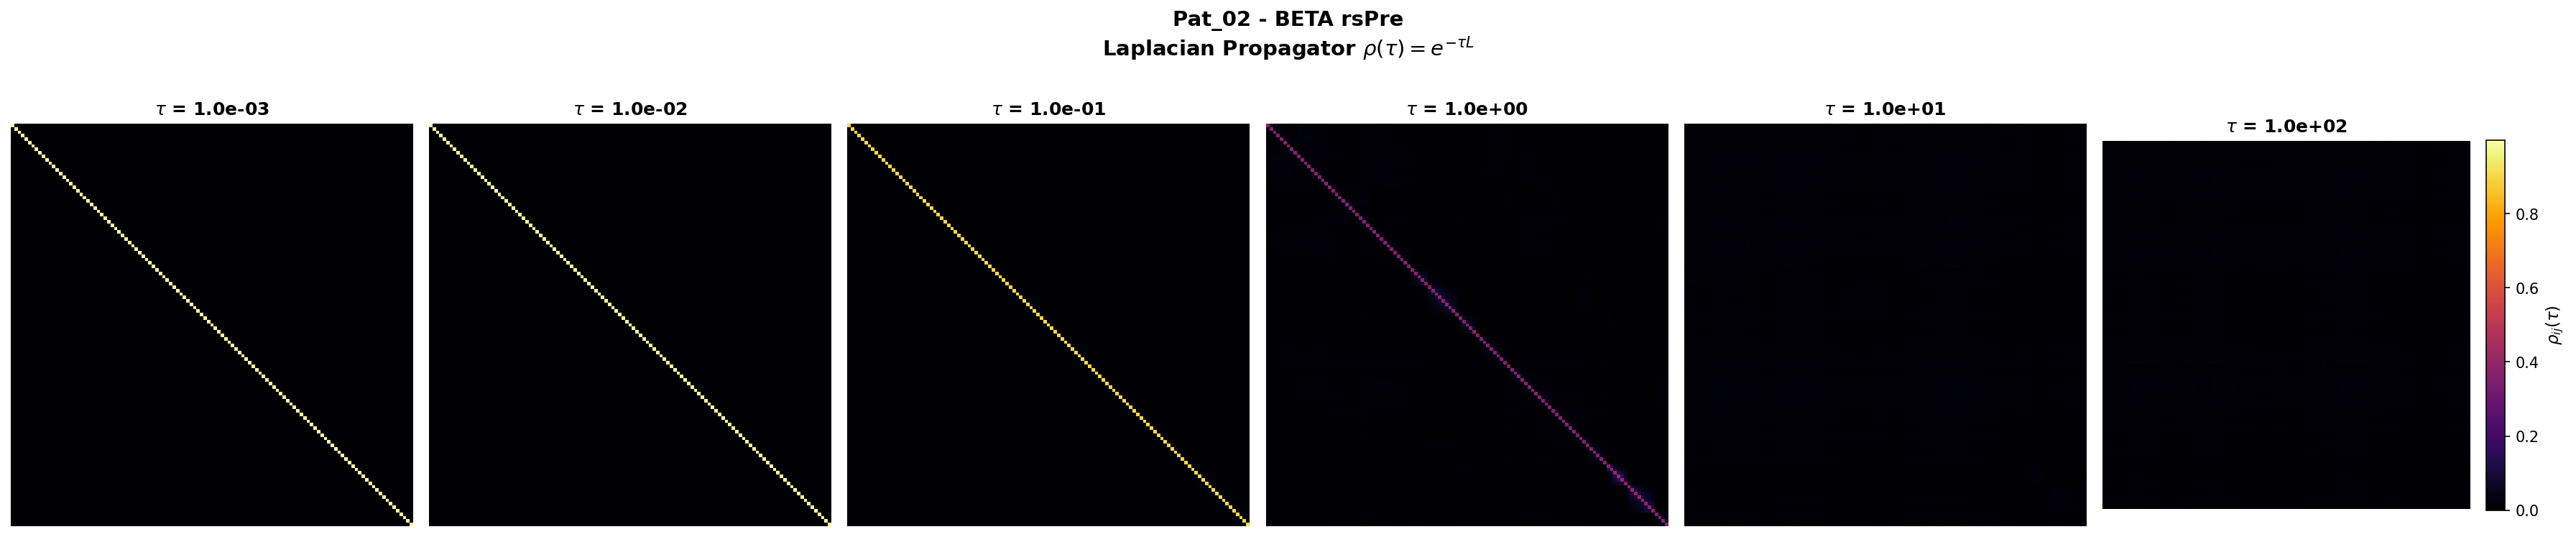

In [9]:
# Generate snapshot figures
TAU_SNAPSHOTS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for band, phase in [("beta", "rsPre")]:
    msc_matrix = load_msc_matrix(
        PATIENT, phase, band,
        cache_root=MSC_CACHE,
        sparsify="none",
    )
    
    if msc_matrix is None:
        continue
    
    fig = plot_rho_snapshots(
        msc_matrix,
        TAU_SNAPSHOTS,
        title=f"{PATIENT} - {band.upper()} {phase}",
        figsize=(24, 5),
    )
    
    output_path = OUTPUT_DIR / f"fig3_rho_snapshots_{band}_{phase}.pdf"
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()
    plt.close(fig)

## Summary

In [10]:
# List all generated files
print("\n" + "="*60)
print("FIGURE 3 GENERATION COMPLETE")
print("="*60)

print(f"\nOutput directory: {OUTPUT_DIR}")
print("\nGenerated files:")

for f in sorted(OUTPUT_DIR.glob("fig3_*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")


FIGURE 3 GENERATION COMPLETE

Output directory: data/figures/presentation_figures/Pat_02

Generated files:
  fig3_lrg_alpha_rsPost.pdf (137.4 KB)
  fig3_lrg_alpha_rsPre.pdf (135.2 KB)
  fig3_lrg_alpha_taskLearn.pdf (134.3 KB)
  fig3_lrg_alpha_taskTest.pdf (135.6 KB)
  fig3_lrg_beta_rsPost.pdf (133.1 KB)
  fig3_lrg_beta_rsPre.pdf (133.7 KB)
  fig3_lrg_beta_taskLearn.pdf (131.3 KB)
  fig3_lrg_beta_taskTest.pdf (131.7 KB)
  fig3_lrg_delta_rsPost.pdf (133.5 KB)
  fig3_lrg_delta_rsPre.pdf (134.7 KB)
  fig3_lrg_delta_taskLearn.pdf (133.5 KB)
  fig3_lrg_delta_taskTest.pdf (133.5 KB)
  fig3_lrg_high_gamma_rsPost.pdf (133.2 KB)
  fig3_lrg_high_gamma_rsPre.pdf (133.2 KB)
  fig3_lrg_high_gamma_taskLearn.pdf (131.7 KB)
  fig3_lrg_high_gamma_taskTest.pdf (132.5 KB)
  fig3_lrg_low_gamma_rsPost.pdf (129.1 KB)
  fig3_lrg_low_gamma_rsPre.pdf (131.1 KB)
  fig3_lrg_low_gamma_taskLearn.pdf (129.1 KB)
  fig3_lrg_low_gamma_taskTest.pdf (128.8 KB)
  fig3_lrg_theta_rsPost.pdf (137.6 KB)
  fig3_lrg_theta_rsPr